🎨 데이터 시각화를 시작합니다!


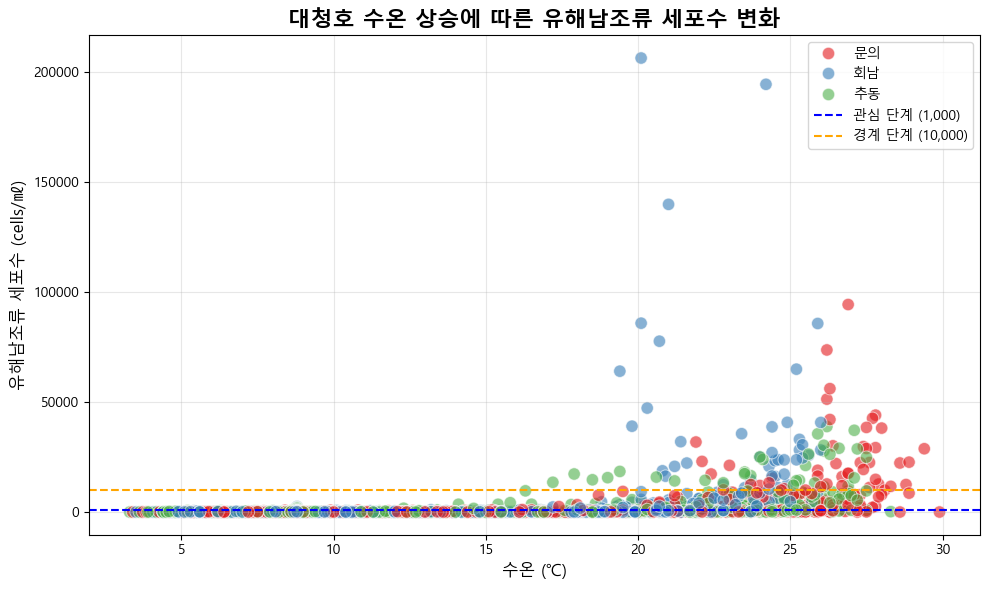

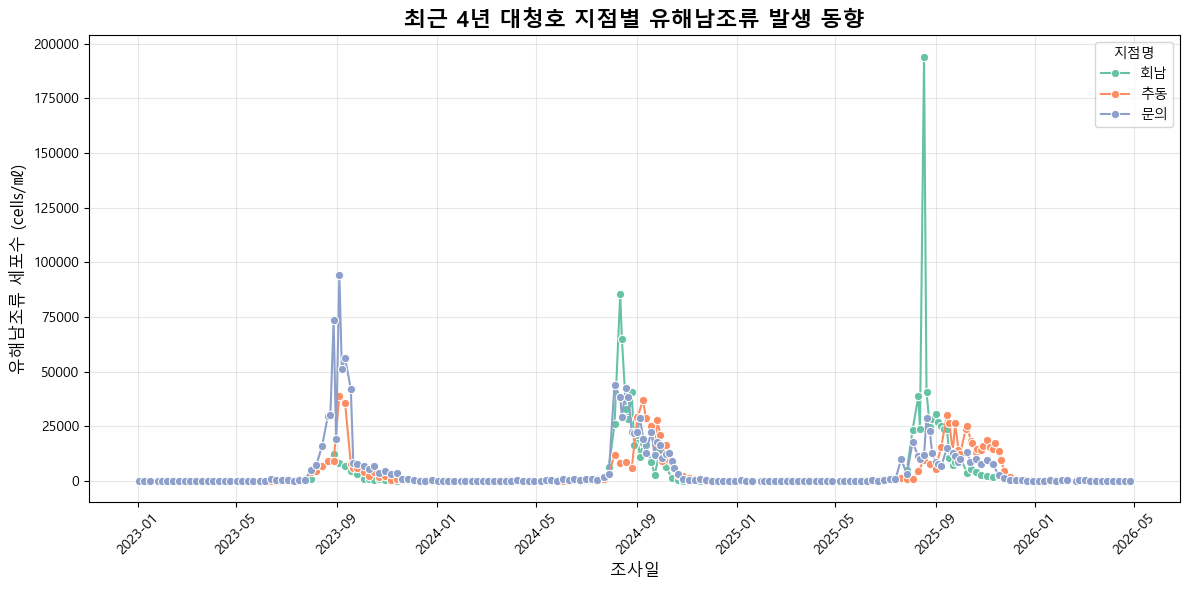

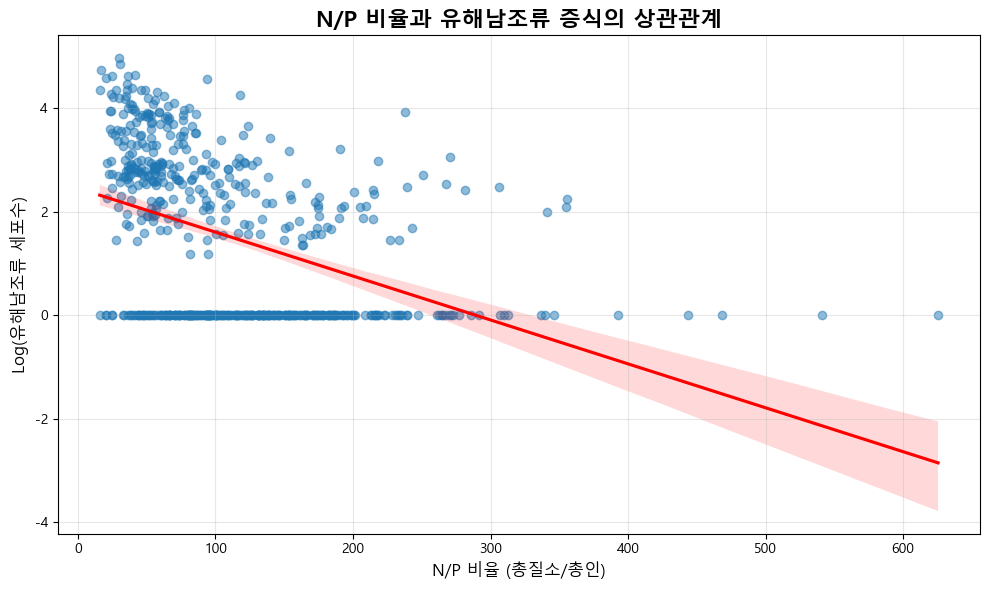

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore') # 성가신 경고 메시지 숨기기

# 1. 한글 폰트 설정 (윈도우 기준 '맑은 고딕')
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 2. 시각화용 데이터 불러오기 (날짜와 지점명이 살아있는 마스터 데이터!)
df_eda = pd.read_csv('대청호_AI_학습용_최종_마스터데이터.csv')

# 날짜 데이터 처리 및 '연도' 컬럼 추출
df_eda['조사일'] = pd.to_datetime(df_eda['조사일'])
df_eda['연도'] = df_eda['조사일'].dt.year

# 남조류 수치가 너무 커서 보기 힘들 수 있으니, +1 후 로그(log10) 변환한 열도 하나 만들어둘게
import numpy as np
df_eda['로그_남조류'] = np.log10(df_eda['유해남조류 세포수 (cells/㎖)'] + 1)

print("🎨 데이터 시각화를 시작합니다!")

# -------------------------------------------------------------
# 📈 그래프 1: 대청호 수온 상승에 따른 유해남조류 세포수 변화 (산점도)
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))
# 데이터가 많이 겹치니까 투명도(alpha)를 주고, 지점별로 색깔(hue)을 다르게!
sns.scatterplot(data=df_eda, x='수온(℃)', y='유해남조류 세포수 (cells/㎖)', hue='채수위치', s=80, alpha=0.6, palette='Set1')

# 그래프 꾸미기
plt.axhline(1000, color='blue', linestyle='--', label='관심 단계 (1,000)')
plt.axhline(10000, color='orange', linestyle='--', label='경계 단계 (10,000)')
plt.title('대청호 수온 상승에 따른 유해남조류 세포수 변화', fontsize=16, fontweight='bold')
plt.xlabel('수온 (℃)', fontsize=12)
plt.ylabel('유해남조류 세포수 (cells/㎖)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 📉 그래프 2: 최근 4년 대청호 지점별 남조류 발생 동향 (시계열 꺾은선)
# -------------------------------------------------------------
# 최근 4년(2023~2026년 가정) 데이터만 필터링
df_recent = df_eda[df_eda['연도'] >= 2023]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_recent, x='조사일', y='유해남조류 세포수 (cells/㎖)', hue='채수위치', marker='o', palette='Set2')

plt.title('최근 4년 대청호 지점별 유해남조류 발생 동향', fontsize=16, fontweight='bold')
plt.xlabel('조사일', fontsize=12)
plt.ylabel('유해남조류 세포수 (cells/㎖)', fontsize=12)
plt.xticks(rotation=45) # 날짜 글씨 겹치지 않게 45도 기울이기
plt.legend(title='지점명')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 🌟 (보너스) 그래프 3: 우리가 새로 만든 'N/P 비율'과 조류의 관계
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))
# 이번엔 Y축을 로그 스케일로 해서 패턴이 더 잘 보이게 그릴게
sns.regplot(data=df_eda, x='N_P_비율', y='로그_남조류', scatter_kws={'alpha':0.5}, line_kws={'color': 'red'})

plt.title('N/P 비율과 유해남조류 증식의 상관관계', fontsize=16, fontweight='bold')
plt.xlabel('N/P 비율 (총질소/총인)', fontsize=12)
plt.ylabel('Log(유해남조류 세포수)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

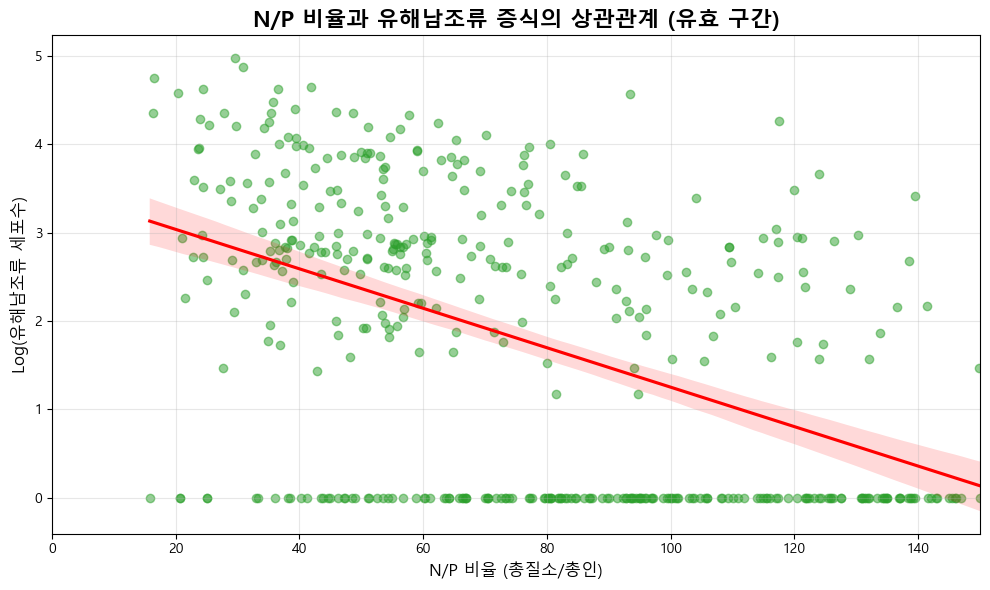

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 1. 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False 

# 2. 데이터 불러오기
df_eda = pd.read_csv('대청호_AI_학습용_최종_마스터데이터.csv')
df_eda['로그_남조류'] = np.log10(df_eda['유해남조류 세포수 (cells/㎖)'] + 1)

# -------------------------------------------------------------
# 🌟 그래프 3: N/P 비율과 조류의 관계 (X축 0~150으로 제한!)
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))

# X축 범위를 미리 제한할 데이터만 필터링해서 추세선(회귀선)이 더 정확하게 그려지게 함!
df_filtered = df_eda[df_eda['N_P_비율'] <= 150]

sns.regplot(data=df_filtered, x='N_P_비율', y='로그_남조류', 
            scatter_kws={'alpha':0.5, 'color':'#2ca02c'}, line_kws={'color': 'red'})

# 🚨 여기가 핵심! X축을 0부터 150까지만 보여주도록 자름
plt.xlim(0, 150)

plt.title('N/P 비율과 유해남조류 증식의 상관관계 (유효 구간)', fontsize=16, fontweight='bold')
plt.xlabel('N/P 비율 (총질소/총인)', fontsize=12)
plt.ylabel('Log(유해남조류 세포수)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()